<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN = Density-Based Spatial Clustering


Instead of forcing K clusters, it says:

 “Let the data decide the number of clusters”


**Core idea**

It groups points based on density:

It uses 3 ideas:
1. Epsilon (ε) : Radius around a point

2. MinPts : Minimum number of points inside that radius

Classification of points:

DBSCAN splits data into:

1.  Core points : enough neighbors inside ε radius

2. Border points : near core points but weaker density

3. Noise (outliers) : doesn’t belong anywhere

**Why DBSCAN is powerful :**

Compared to K-Means:

| K-Means                      | DBSCAN                     |
| ---------------------------- | -------------------------- |
| Needs K                      | No K required              |
| Only spherical clusters      | Any shape                  |
| Sensitive to outliers        | Detects outliers           |
| Works with balanced clusters | Works with messy real data |



### 1. Creating Data

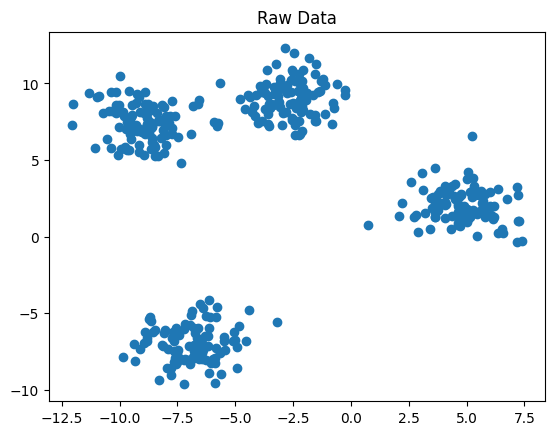

In [2]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Raw Data")
plt.show()

### 2. Scaling

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### K-Means on scaled data:

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_

### Plot:

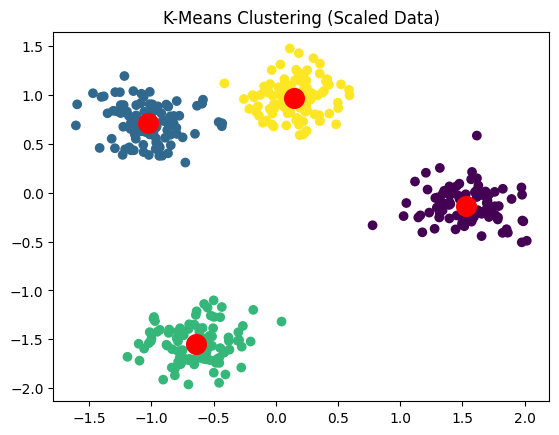

In [5]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red')
plt.title("K-Means Clustering (Scaled Data)")
plt.show()

### Elbow Method (with SAME data)

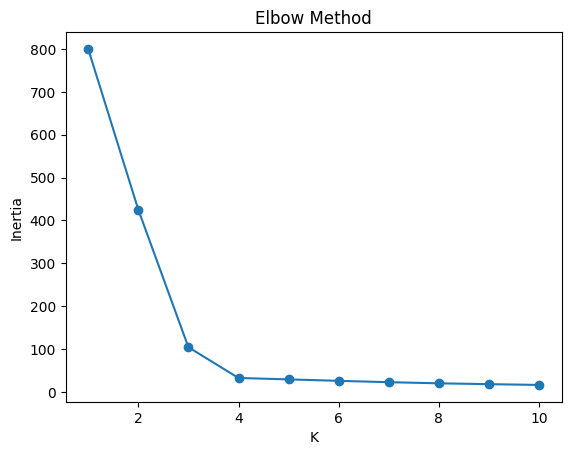

In [8]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### DBSCAN

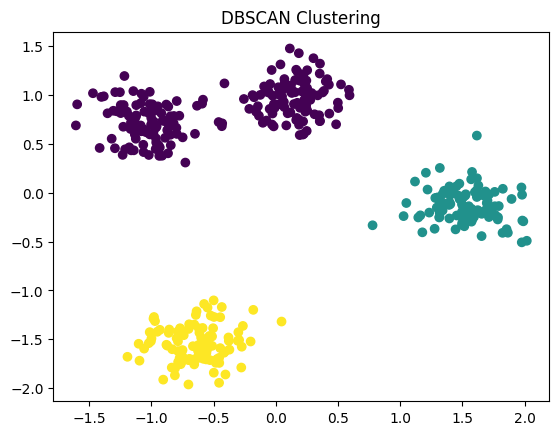

In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.show()

## Configuring DBSCAN Manually with hyperparameters

### eps : a distance threshold you set manually

You are telling the algo how much distance is counted as near.

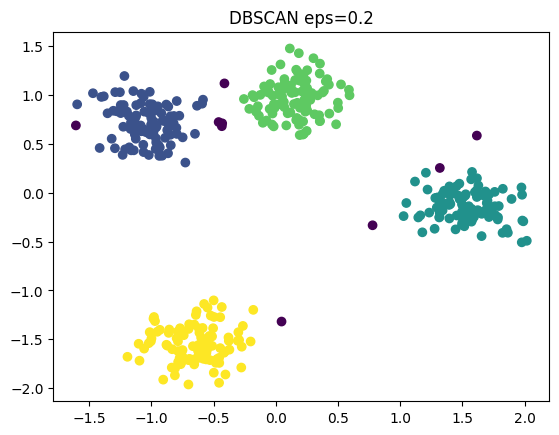

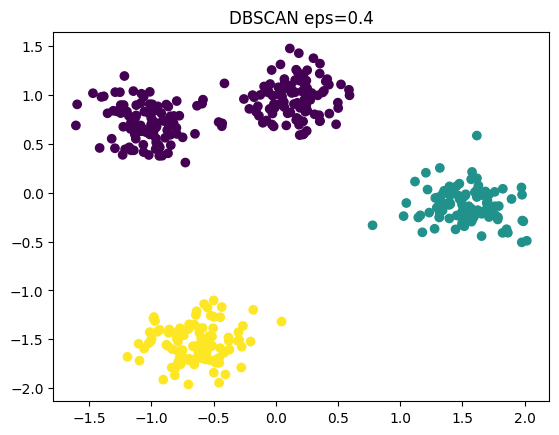

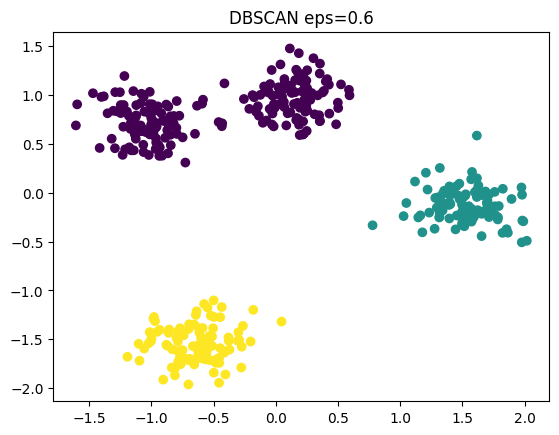

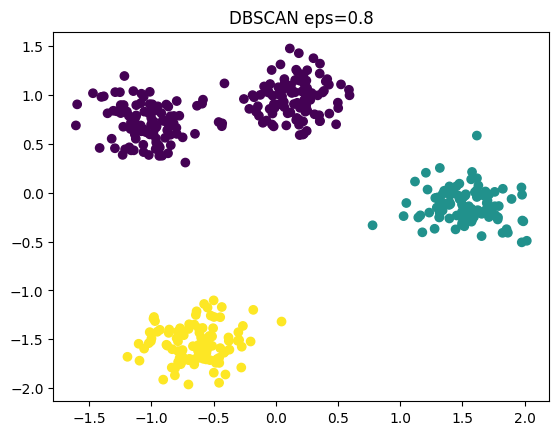

In [11]:
for eps in [0.2, 0.4, 0.6, 0.8]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)

    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
    plt.title(f"DBSCAN eps={eps}")
    plt.show()

Radius around a point.

small eps → too strict → everything becomes noise
big eps → everything merges into one cluster

#### K-distance graph for eps:

This is the standard approach.

Idea:

For each point:

find distance to its k-th nearest neighbor (k = min_samples)
sort those distances
plot them

Then:
 the “bend” in the graph = good eps

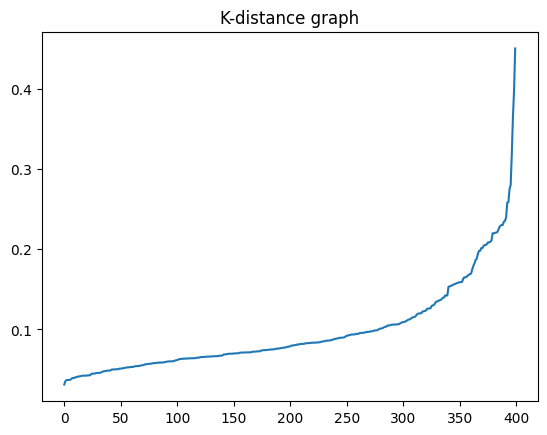

In [12]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])  # 4 = k-1 because index starts at 0

plt.plot(distances)
plt.title("K-distance graph")
plt.show()

flat region → normal points

sudden spike → noise starts

 eps = value just BEFORE the spike

Domain knowledge (real-world ML)

Example:

GPS data → eps = few meters

customer data → eps depends on scaling

image embeddings → very different scale

### min_samples: Minimum points needed to form a cluster

* small → too many fake clusters
* large → only dense regions survive

rule of thumb

> A common starting point: min_samples ≈ 2 × number_of_features

So if:

2D data → start with ~4 or 5
higher dimensions → increase it


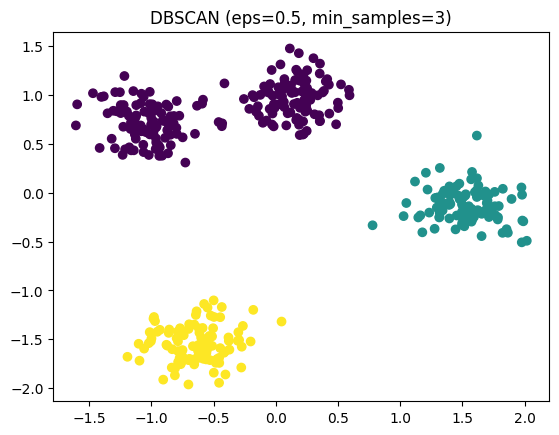

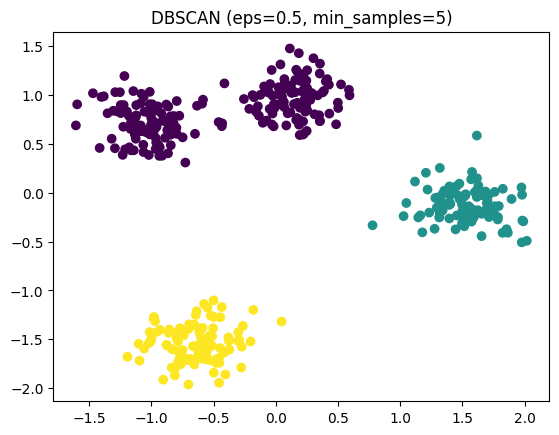

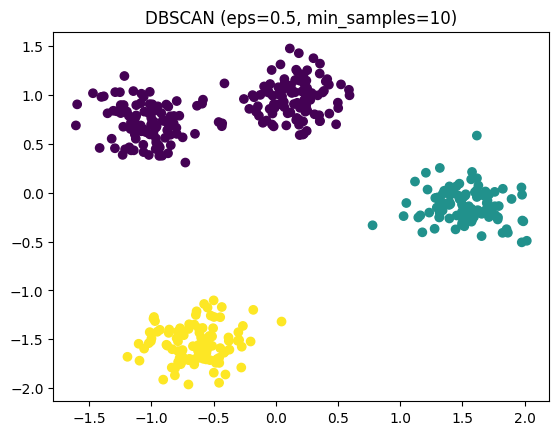

In [13]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

for ms in [3, 5, 10]:
    dbscan = DBSCAN(eps=0.5, min_samples=ms)
    labels = dbscan.fit_predict(X_scaled)

    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
    plt.title(f"DBSCAN (eps=0.5, min_samples={ms})")
    plt.show()

If min_samples = 3:
* more clusters
* more sensitive
* may pick noise as clusters

If min_samples = 10
* fewer clusters
* more noise (-1)
* more strict grouping

DBSCAN is NOT “run and done”.

It is: “tune eps + min_samples until structure makes sense”

**K-Means:**

> I will split data into K groups no matter what

**DBSCAN:**

>I will find groups only where density exists